PhishSense AI

In [148]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

In [149]:
df = pd.read_csv('CEAS_08.csv')

In [150]:
df.head()

,sender,receiver,date,subject,body,label,urls
0,Young Esposito <Young@iworld.de>,user4@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 16:31:02 -0700",Never agree to be a loser,"Buck up, your troubles caused by small dimensi...",1,1
1,Mok <ipline's1983@icable.ph>,user2.2@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 18:31:03 -0500",Befriend Jenna Jameson,\nUpgrade your sex and pleasures with these te...,1,1
2,Daily Top 10 <Karmandeep-opengevl@universalnet...,user2.9@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 20:28:00 -1200",CNN.com Daily Top 10,>+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+...,1,1
3,Michael Parker <ivqrnai@pobox.com>,SpamAssassin Dev <xrh@spamassassin.apache.org>,"Tue, 05 Aug 2008 17:31:20 -0600",Re: svn commit: r619753 - in /spamassassin/tru...,Would anyone object to removing .so from this ...,0,1
4,Gretchen Suggs <externalsep1@loanofficertool.com>,user2.2@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 19:31:21 -0400",SpecialPricesPharmMoreinfo,\nWelcomeFastShippingCustomerSupport\nhttp://7...,1,1


In [151]:
df.shape

(39154, 7)

In [152]:
df.columns

Index(['sender', 'receiver', 'date', 'subject', 'body', 'label', 'urls'], dtype='str')

In [153]:
df.isnull().sum()

sender        0
receiver    462
date          0
subject      28
body          0
label         0
urls          0
dtype: int64

In [154]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 39154 entries, 0 to 39153
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   sender    39154 non-null  str  
 1   receiver  38692 non-null  str  
 2   date      39154 non-null  str  
 3   subject   39126 non-null  str  
 4   body      39154 non-null  str  
 5   label     39154 non-null  int64
 6   urls      39154 non-null  int64
dtypes: int64(2), str(5)
memory usage: 66.3 MB


In [155]:
df.drop(columns= ['sender', 'receiver','date'], inplace= True)

In [156]:
df.shape

(39154, 4)

In [157]:
df['subject'] = df['subject'].fillna('')

In [158]:
df.isnull().sum()

subject    0
body       0
label      0
urls       0
dtype: int64

In [159]:
df['label'].value_counts()

label
1    21842
0    17312
Name: count, dtype: int64

In [160]:
df.groupby('label')['body'].count()

label
0    17312
1    21842
Name: body, dtype: int64

In [161]:
df.duplicated().sum()

np.int64(0)

In [162]:
df['text'] = df['subject'] + ' '+ df['body']

In [163]:
df.drop(columns=['body', 'subject'], inplace= True)

In [164]:
df.head()

,label,urls,text
0,1,1,"Never agree to be a loser Buck up, your troubl..."
1,1,1,Befriend Jenna Jameson \nUpgrade your sex and ...
2,1,1,CNN.com Daily Top 10 >+=+=+=+=+=+=+=+=+=+=+=+=...
3,0,1,Re: svn commit: r619753 - in /spamassassin/tru...
4,1,1,SpecialPricesPharmMoreinfo \nWelcomeFastShippi...


In [165]:
df['text'] = df['text'].apply(lambda x : x.lower())

In [166]:
import string 

def remove_punc(txt):
    return txt.translate(str.maketrans('', '',string.punctuation))

In [167]:
df['text'] = df['text'].apply(remove_punc)

In [168]:
import re

def urls(txt):
    return re.sub(r'http\S+|www\S+', '',txt)

In [169]:
df['text'] = df['text'].apply(urls)

In [170]:
def html(txt):
    return re.sub(r'<.*?>','',txt)

In [171]:
df['text'] = df['text'].apply(html)

In [172]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [173]:
stop_w = set(stopwords.words('english'))

In [174]:
def remove_sw(txt):
    words = word_tokenize(str(txt), preserve_line=True)
    cleaned = []

    for i in words:
        if i not in stop_w:
            cleaned.append(i)

    return ' '.join(cleaned)

In [175]:
df['text'] = df['text'].apply(remove_sw)

In [176]:
df

,label,urls,text
0,1,1,never agree loser buck troubles caused small d...
1,1,1,befriend jenna jameson upgrade sex pleasures t...
2,1,1,cnncom daily top 10 daily top 10 cnncom top vi...
3,0,1,svn commit r619753 spamassassintrunk libmailsp...
4,1,1,specialpricespharmmoreinfo welcomefastshipping...
...,...,...,...
39149,1,0,cnn alerts custom alert cnn alerts custom aler...
39150,1,0,cnn alerts custom alert cnn alerts custom aler...
39151,0,0,slideshow viewer hello great work slide show v...
39152,0,0,note 2digit years mail sender coming intuitcom...


In [177]:
df.drop(columns= ['urls'], inplace = True)

In [178]:
df.head()

,label,text
0,1,never agree loser buck troubles caused small d...
1,1,befriend jenna jameson upgrade sex pleasures t...
2,1,cnncom daily top 10 daily top 10 cnncom top vi...
3,0,svn commit r619753 spamassassintrunk libmailsp...
4,1,specialpricespharmmoreinfo welcomefastshipping...


In [179]:
X = df['text']
y = df['label']

In [180]:
from sklearn.model_selection import train_test_split

In [181]:
X_train, X_test, y_train, y_test= train_test_split(
    X,y,
    random_state= 42,
    test_size= 0.2
)

In [182]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [183]:
tfidf = TfidfVectorizer()
X_train_tf=tfidf.fit_transform(X_train)
X_test_tf= tfidf.transform(X_test)

In [184]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_ngram = TfidfVectorizer(ngram_range=(1, 2))

X_train_ngram = tfidf_ngram.fit_transform(X_train)
X_test_ngram = tfidf_ngram.transform(X_test)

Logistic regression classifier

In [185]:
from sklearn.linear_model import LogisticRegression

In [191]:
model_logistic_tf  = LogisticRegression(max_iter=1000)
model_logistic_tf.fit(X_train_tf, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [192]:
y_pred_lr_tf = model_logistic_tf.predict(X_test_tf)

In [193]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred_lr_tf))
print(classification_report(y_test, y_pred_lr_tf))

Accuracy: 0.9939982122334312
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      3490
           1       0.99      1.00      0.99      4341

    accuracy                           0.99      7831
   macro avg       0.99      0.99      0.99      7831
weighted avg       0.99      0.99      0.99      7831



Logistic regression on n-grams

In [190]:
model_logistic_ngram = LogisticRegression(max_iter=1000)

model_logistic_ngram.fit(X_train_ngram, y_train)



,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [194]:
y_pred_ngram = model_logistic_ngram.predict(X_test_ngram)

In [195]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred_ngram))
print(classification_report(y_test, y_pred_ngram))

Accuracy: 0.9952751883539778
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      3490
           1       1.00      0.99      1.00      4341

    accuracy                           1.00      7831
   macro avg       1.00      1.00      1.00      7831
weighted avg       1.00      1.00      1.00      7831



Naive Bayes

In [196]:
from sklearn.naive_bayes import MultinomialNB

model_nb = MultinomialNB()

model_nb.fit(X_train_ngram, y_train)



,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](2,)","[13822.,17501.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Smoothed empirical log probability for each class.","ndarray[float64](2,)","[-0.82,-0.58]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"feature_count_ feature_count_: ndarray of shape (n_classes, n_features)Number of samples encountered for each (class, feature)during fitting. This value is weighted by the sample weight whenprovided.","ndarray[float64](2, 1458141)","[[6.76,0.4 ,0.18,...,0.08,0. ,0. ], [0. ,0. ,0. ,...,0. ,0.1 ,0.1 ]]"
"feature_log_prob_ feature_log_prob_: ndarray of shape (n_classes, n_features)Empirical log probability of featuresgiven a class, ``P(x_i|y)``.","ndarray[float64](2, 1458141)","[[-12.26,-13.97,-14.15,...,-14.24,-14.31,-14.31], [-14.28,-14.28,-14.28,...,-14.28,-14.19,-14.19]]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1458141


In [197]:
y_pred_nb = model_nb.predict(X_test_ngram)

In [198]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred_nb))
print(classification_report(y_test, y_pred_nb))

Accuracy: 0.9937428170093219
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      3490
           1       1.00      0.99      0.99      4341

    accuracy                           0.99      7831
   macro avg       0.99      0.99      0.99      7831
weighted avg       0.99      0.99      0.99      7831



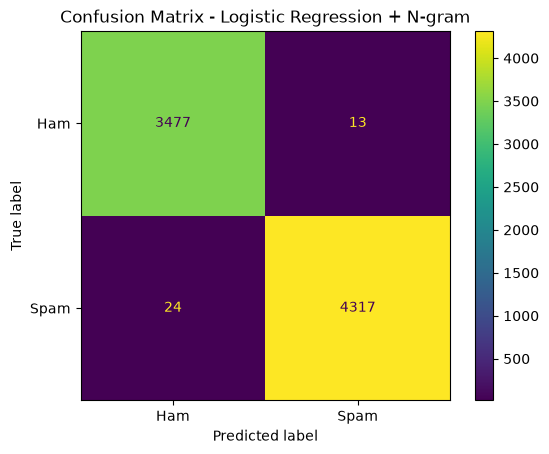

In [199]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_ngram)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Ham', 'Spam']
)

disp.plot()
plt.title("Confusion Matrix - Logistic Regression + N-gram")
plt.show()

In [200]:
import joblib

joblib.dump(model_logistic_tf, "spam_model.pkl")
joblib.dump(model_logistic_ngram, "ngram_vectorizer.pkl")

['ngram_vectorizer.pkl']

In [201]:
import os

print(os.path.exists("spam_model.pkl"))
print(os.path.exists("ngram_vectorizer.pkl"))

True
True


In [202]:
%whos

Variable                 Type                      Data/Info
------------------------------------------------------------
ConfusionMatrixDisplay   type                      <class 'sklearn.metrics._<...>.ConfusionMatrixDisplay'>
LogisticRegression       type                      <class 'sklearn.linear_mo<...>stic.LogisticRegression'>
MultinomialNB            ABCMeta                   <class 'sklearn.naive_bayes.MultinomialNB'>
TfidfVectorizer          type                      <class 'sklearn.feature_e<...>on.text.TfidfVectorizer'>
X                        Series                    Shape: (39154,)
X_test                   Series                    Shape: (7831,)
X_test_ngram             csr_matrix                <Compressed Sparse Row sp<...>7442)	0.10521066135120308
X_test_tf                csr_matrix                <Compressed Sparse Row sp<...>80162)	0.1523595939254308
X_train                  Series                    Shape: (31323,)
X_train_ngram            csr_matrix             